Sample:    152 pts, T = [-14.6, 14.0] °C
No sample: 350 pts, T = [-13.9, 14.9] °C


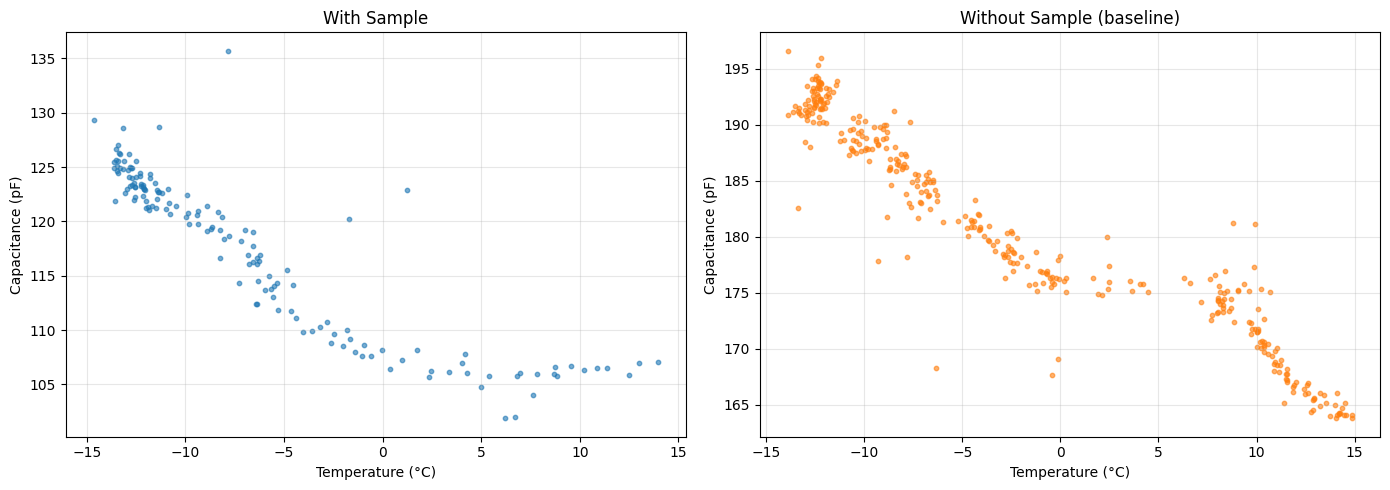

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load both datasets
df_sample = pd.read_csv('final_data/sample_capacitances.csv')
df_nosample = pd.read_csv('final_data/no_sample_capacitances.csv')

# Convert to pF
df_sample['capacitance_pF'] = df_sample['capacitance_value'] * 1e12
df_nosample['capacitance_pF'] = df_nosample['capacitance_value'] * 1e12

# Reliable temperature ranges
T_MIN_SAMPLE, T_MAX = -15, 15
T_MIN_NOSAMPLE = T_MIN_SAMPLE

df_s = df_sample[(df_sample['temperature_C'] >= T_MIN_SAMPLE) & (df_sample['temperature_C'] <= T_MAX)].copy()
df_n = df_nosample[(df_nosample['temperature_C'] >= T_MIN_NOSAMPLE) & (df_nosample['temperature_C'] <= T_MAX)].copy()

# Remove capacitance outliers (> 3 sigma from rolling median)
for label, d in [('sample', df_s), ('no_sample', df_n)]:
    med = d['capacitance_pF'].median()
    std = d['capacitance_pF'].std()
    mask = (d['capacitance_pF'] > med - 3*std) & (d['capacitance_pF'] < med + 3*std)
    if label == 'sample':
        df_s = d[mask].copy()
    else:
        df_n = d[mask].copy()

print(f"Sample:    {len(df_s)} pts, T = [{df_s['temperature_C'].min():.1f}, {df_s['temperature_C'].max():.1f}] °C")
print(f"No sample: {len(df_n)} pts, T = [{df_n['temperature_C'].min():.1f}, {df_n['temperature_C'].max():.1f}] °C")

# Plot both datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.6, color='tab:blue')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Capacitance (pF)')
ax1.set_title('With Sample')
ax1.grid(True, alpha=0.3)

ax2.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.6, color='tab:orange')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Capacitance (pF)')
ax2.set_title('Without Sample (baseline)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With sample:    dC/dT = -0.915983 pF/°C
Without sample: dC/dT = -0.920889 pF/°C


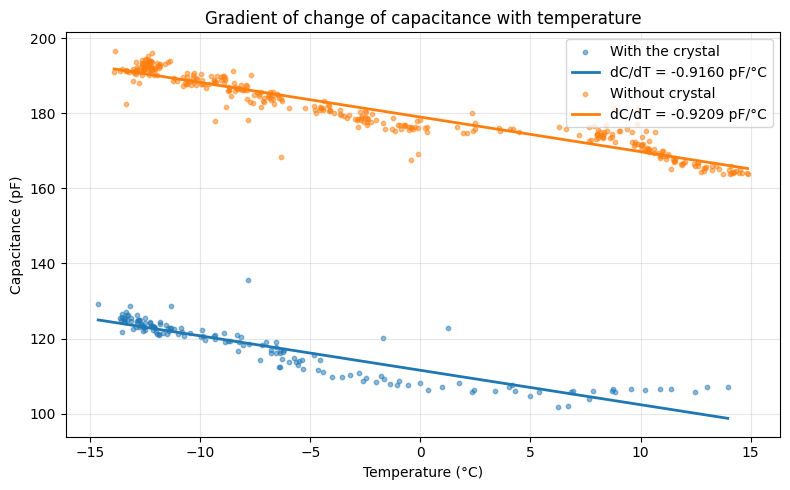

In [382]:
# Linear fit: capacitance_pF = m * temperature_C + b
m_s, b_s = np.polyfit(df_s['temperature_C'], df_s['capacitance_pF'], 1)
m_n, b_n = np.polyfit(df_n['temperature_C'], df_n['capacitance_pF'], 1)

print(f"With sample:    dC/dT = {m_s:.6f} pF/°C")
print(f"Without sample: dC/dT = {m_n:.6f} pF/°C")

# Plot fits
t_s_fit = np.linspace(df_s['temperature_C'].min(), df_s['temperature_C'].max(), 200)
t_n_fit = np.linspace(df_n['temperature_C'].min(), df_n['temperature_C'].max(), 200)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.5, label='With the crystal', color='tab:blue')
ax.plot(t_s_fit, m_s * t_s_fit + b_s, color='tab:blue', linewidth=2,
        label=f'dC/dT = {m_s:.4f} pF/°C')

ax.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.5, label='Without crystal', color='tab:orange')
ax.plot(t_n_fit, m_n * t_n_fit + b_n, color='tab:orange', linewidth=2,
        label=f'dC/dT = {m_n:.4f} pF/°C')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Capacitance (pF)')
ax.set_title('Gradient of change of capacitance with temperature')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
A = 25e-4  # m^2
#L0 = 4.58 cm
L0 = 0.0458  # m
air_permittivity = 8.854e-12  # F/m
D0 = (air_permittivity * A) / L0  # F
C0 = 97.21840192016252*1e-12  # F, capacitance at 0°C with sample

K = D0/(L0 * C0)
m_s = m_s #* 1e-12  # Convert from pF/°C to F/°C
m_n = m_n #* 1e-12  # Convert from pF/°C to F/°C
alpha = K*(m_s - m_n)

print(f"Estimated thermal expansion coefficient: alpha = {alpha * 1e5} x 10^-5 1/°C")

Estimated thermal expansion coefficient: alpha = 53.2501615824644 x 10^-5 1/°C
